## Establishing Risk Factors for CVD using Logistic Regression: Data Cleaning
##### Lilah DuBoff

>First, let's load our packages and data in

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uci_cleveland_data = pd.read_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/01_OG_Data/UC_Irvine_Data/processed.cleveland.data",
    header=None,
)

bangladesh_data = pd.read_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/01_OG_Data/CAIR-CVD-2025 An Extensive Cardiovascular Disease Risk Assessment Dataset from Bangladesh/bangladesh_cvd.csv"
)

### Information from Data Codebook and Website

14 variables used including predictor        
     

| Variable | Definition/info |
|----------|-----------------|
| age | age in years |
|sex | sex (1 = male; 0 = female) |
|cp  |  9 cp: chest pain type: Value 1: typical angina, Value 2: atypical angina, Value 3: non-anginal pain, Value 4: asymptomatic|
| trestbps | resting blood pressure (in mm Hg on admission to the hospital) |
|chol | serum cholestoral in mg/dl |
|fbs | (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false) |
| restecg | resting electrocardiographic results - Value 0: normal; Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV); Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria |
|thalach | maximum heart rate achieved |
|exang | exercise induced angina (1 = yes; 0 = no) |
|oldpeak | ST depression induced by exercise relative to rest |
|slope | the slope of the peak exercise ST segment - Value 1: upsloping; Value 2: flat; Value 3: downsloping|
|ca | number of major vessels (0-3) colored by flourosopy |
|thal | 3 = normal; 6 = fixed defect; 7 = reversable defect |
|num | the predicted attribute, diagnosis of heart disease (angiographic disease status) - Value 0: < 50% diameter narrowing; Value 1: > 50% diameter narrowing (in any major vessel: attributes 59 through 68 are vessels)|


want to add these in too, but they are not from the processed data - we will try to tackle that later

     13 smoke: I believe this is 1 = yes; 0 = no (is or is not a smoker)
     14 cigs (cigarettes per day)
     15 years (number of years as a smoker)
     17 dm (1 = history of diabetes; 0 = no such history)

In [4]:
headers = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]

### Processed UCI Data from Cleveland

In [5]:
uci_cleveland_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
uci_cleveland_data.columns = headers
uci_cleveland_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [7]:
uci_cleveland_data.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
num           int64
dtype: object

In [8]:
uci_cleveland_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

>Based on this, it would appear there are no missing values. However, upon manual inspection, there are several ? marks, which likely indicate missing data. -9 values should also be searched for

In [9]:
uci_cleveland_data_copy = uci_cleveland_data.copy()
uci_cleveland_data_copy = uci_cleveland_data_copy.astype(str)
qs_and_9s = uci_cleveland_data[
    uci_cleveland_data[
        [
            "age",
            "sex",
            "cp",
            "trestbps",
            "chol",
            "fbs",
            "restecg",
            "thalach",
            "exang",
            "oldpeak",
        ]
    ]
    .isin(["?", "-9"])
    .any(axis=1)
]

# Display the rows with '?' or '-9' values
print(qs_and_9s.head())

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, num]
Index: []


In [10]:
print(uci_cleveland_data_copy.iloc[[287, 302]])

      age  sex   cp trestbps   chol  fbs restecg thalach exang oldpeak slope  \
287  58.0  1.0  2.0    125.0  220.0  0.0     0.0   144.0   0.0     0.4   2.0   
302  38.0  1.0  3.0    138.0  175.0  0.0     0.0   173.0   0.0     0.0   1.0   

    ca thal num  
287  ?  7.0   0  
302  ?  3.0   0  


>See, ca has ? but they can't be removed. Not sure why this is

In [11]:
uci_cleveland_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


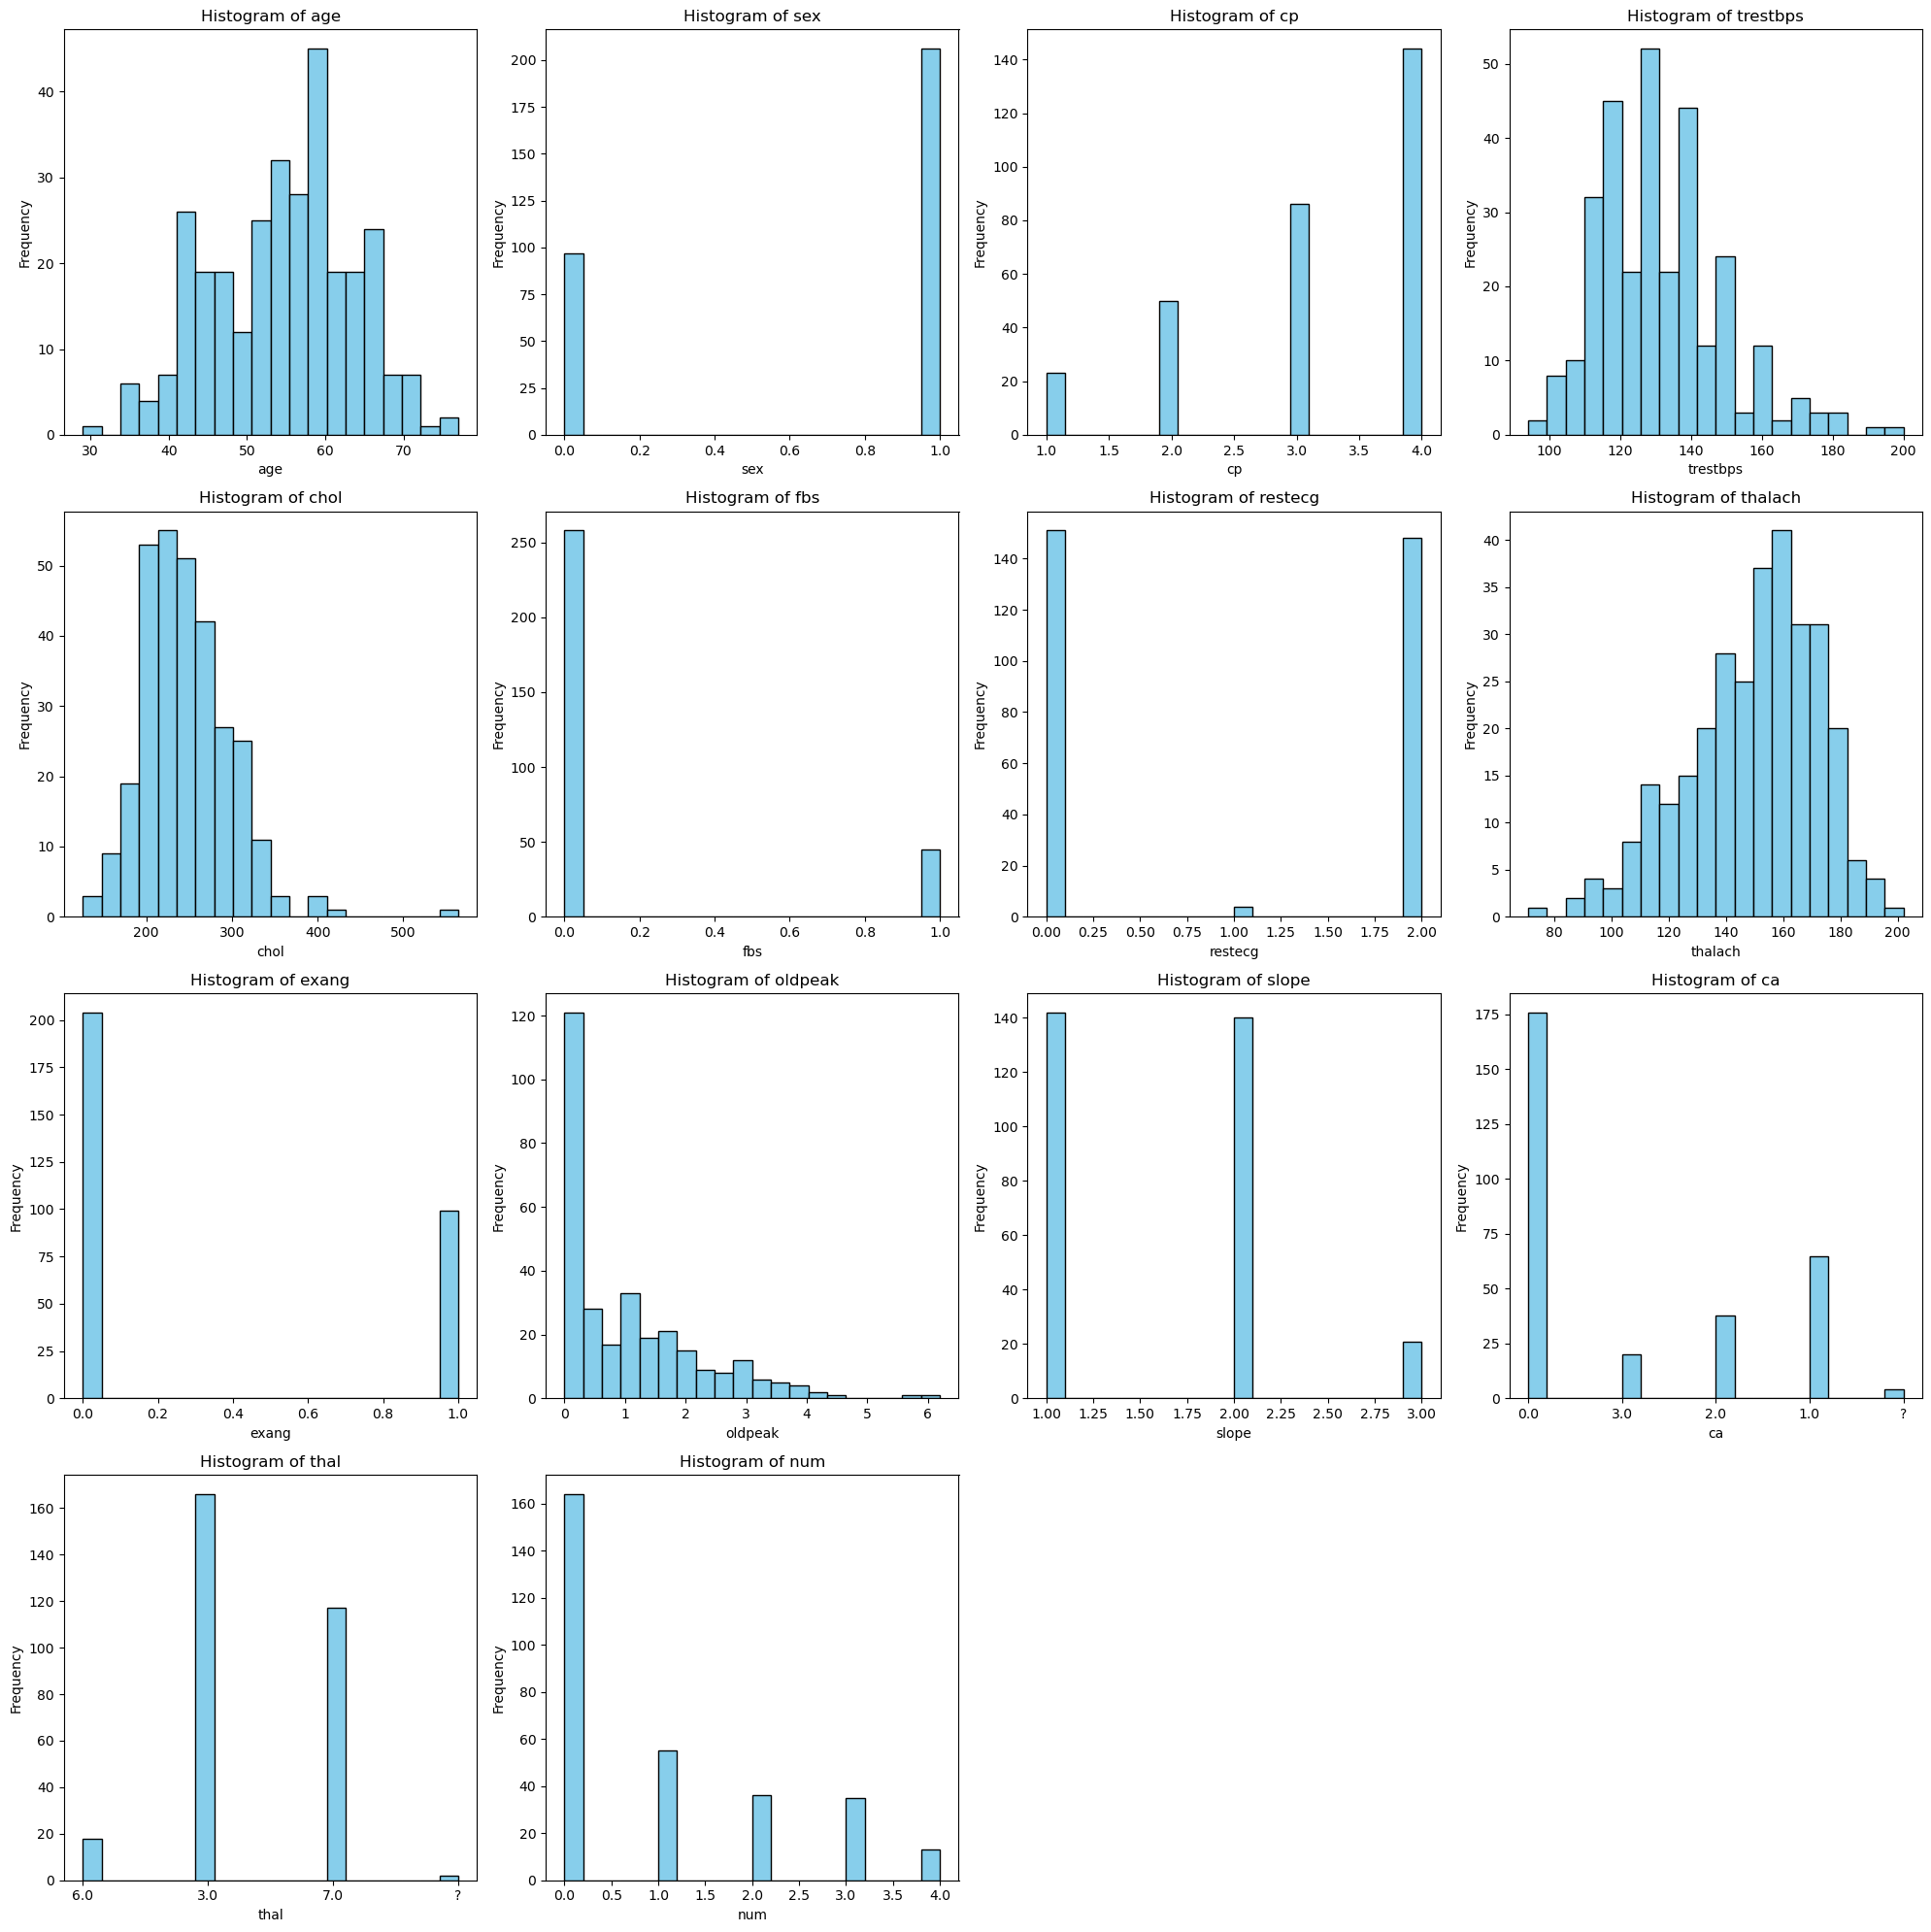

In [12]:
variables = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]

plt.figure(figsize=(20, 20))

for i, var in enumerate(variables, 1):
    plt.subplot(4, 4, i)  # Creates a 4x4 grid for histograms
    plt.hist(
        uci_cleveland_data[var], bins=20, color="skyblue", edgecolor="black"
    )  # Customize bins and colors as needed
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

# Adjust layout to prevent overlapping of plots
plt.tight_layout()
plt.show()

In [13]:
uci_cleveland_data.to_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/00_Cleaned_Data/uci_cleveland_data.csv",
    index=False,
)

### Unprocessed Cleveland Data

In [14]:
# unprocessed_cleveland_data = pd.read_csv(
#     "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/LD_data/UC_Irvine_Data/cleveland.data",
#     header=None,
#     encoding="ISO-8859-1",  # Use an appropriate encoding (like ISO-8859-1 to handle special characters)
#     sep=r"\s+",
#     error_bad_lines=False,
# )

# unprocessed_cleveland_data.head()

### Data from Bangladesh

In [15]:
bangladesh_data.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,CVD Risk Level,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,INTERMEDIARY,171.0,0.504,125.0,79.0,Elevated,140.0,17.93
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,HIGH,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,INTERMEDIARY,183.0,0.583,104.0,77.0,Normal,0.0,12.64
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,INTERMEDIARY,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,INTERMEDIARY,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88


In [16]:
bangladesh_data.isnull().sum()

Sex                              0
Age                             78
Weight (kg)                     81
Height (m)                      67
BMI                             64
Abdominal Circumference (cm)    67
Blood Pressure (mmHg)            0
Total Cholesterol (mg/dL)       73
HDL (mg/dL)                     80
Fasting Blood Sugar (mg/dL)     67
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
CVD Risk Level                   0
Height (cm)                     74
Waist-to-Height Ratio           79
Systolic BP                     71
Diastolic BP                    82
Blood Pressure Category          0
Estimated LDL (mg/dL)           69
CVD Risk Score                  70
dtype: int64

In [17]:
bangladesh_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

In [18]:
bangladesh_data.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1451.000000,1448.000000,1462.000000,1465.000000,1462.000000,1456.000000,1449.000000,1462.000000,1455.000000,1450.000000,1458.000000,1447.000000,1460.000000,1459.000000
mean,47.025500,85.917427,1.754111,28.465997,91.773214,198.539148,56.197378,117.485636,175.390600,0.525727,125.627572,82.917761,111.550685,16.960925
std,12.421063,21.012580,0.113090,7.038685,12.823573,57.794099,16.066754,30.289174,11.251527,0.081213,22.112099,14.731277,58.866220,2.436192
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,-18.000000,10.530000
25%,37.000000,67.050000,1.660000,22.629000,80.500000,150.000000,42.000000,92.000000,166.000000,0.460000,107.000000,71.000000,61.000000,15.205000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,109.000000,16.880000
75%,55.000000,105.000000,1.845500,34.000000,102.269000,249.000000,70.000000,138.000000,184.208500,0.583750,141.000000,93.000000,159.000000,18.630000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


In [19]:
bangladesh_data.columns

Index(['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)',
       'Total Cholesterol (mg/dL)', 'HDL (mg/dL)',
       'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD', 'CVD Risk Level',
       'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score'],
      dtype='object')

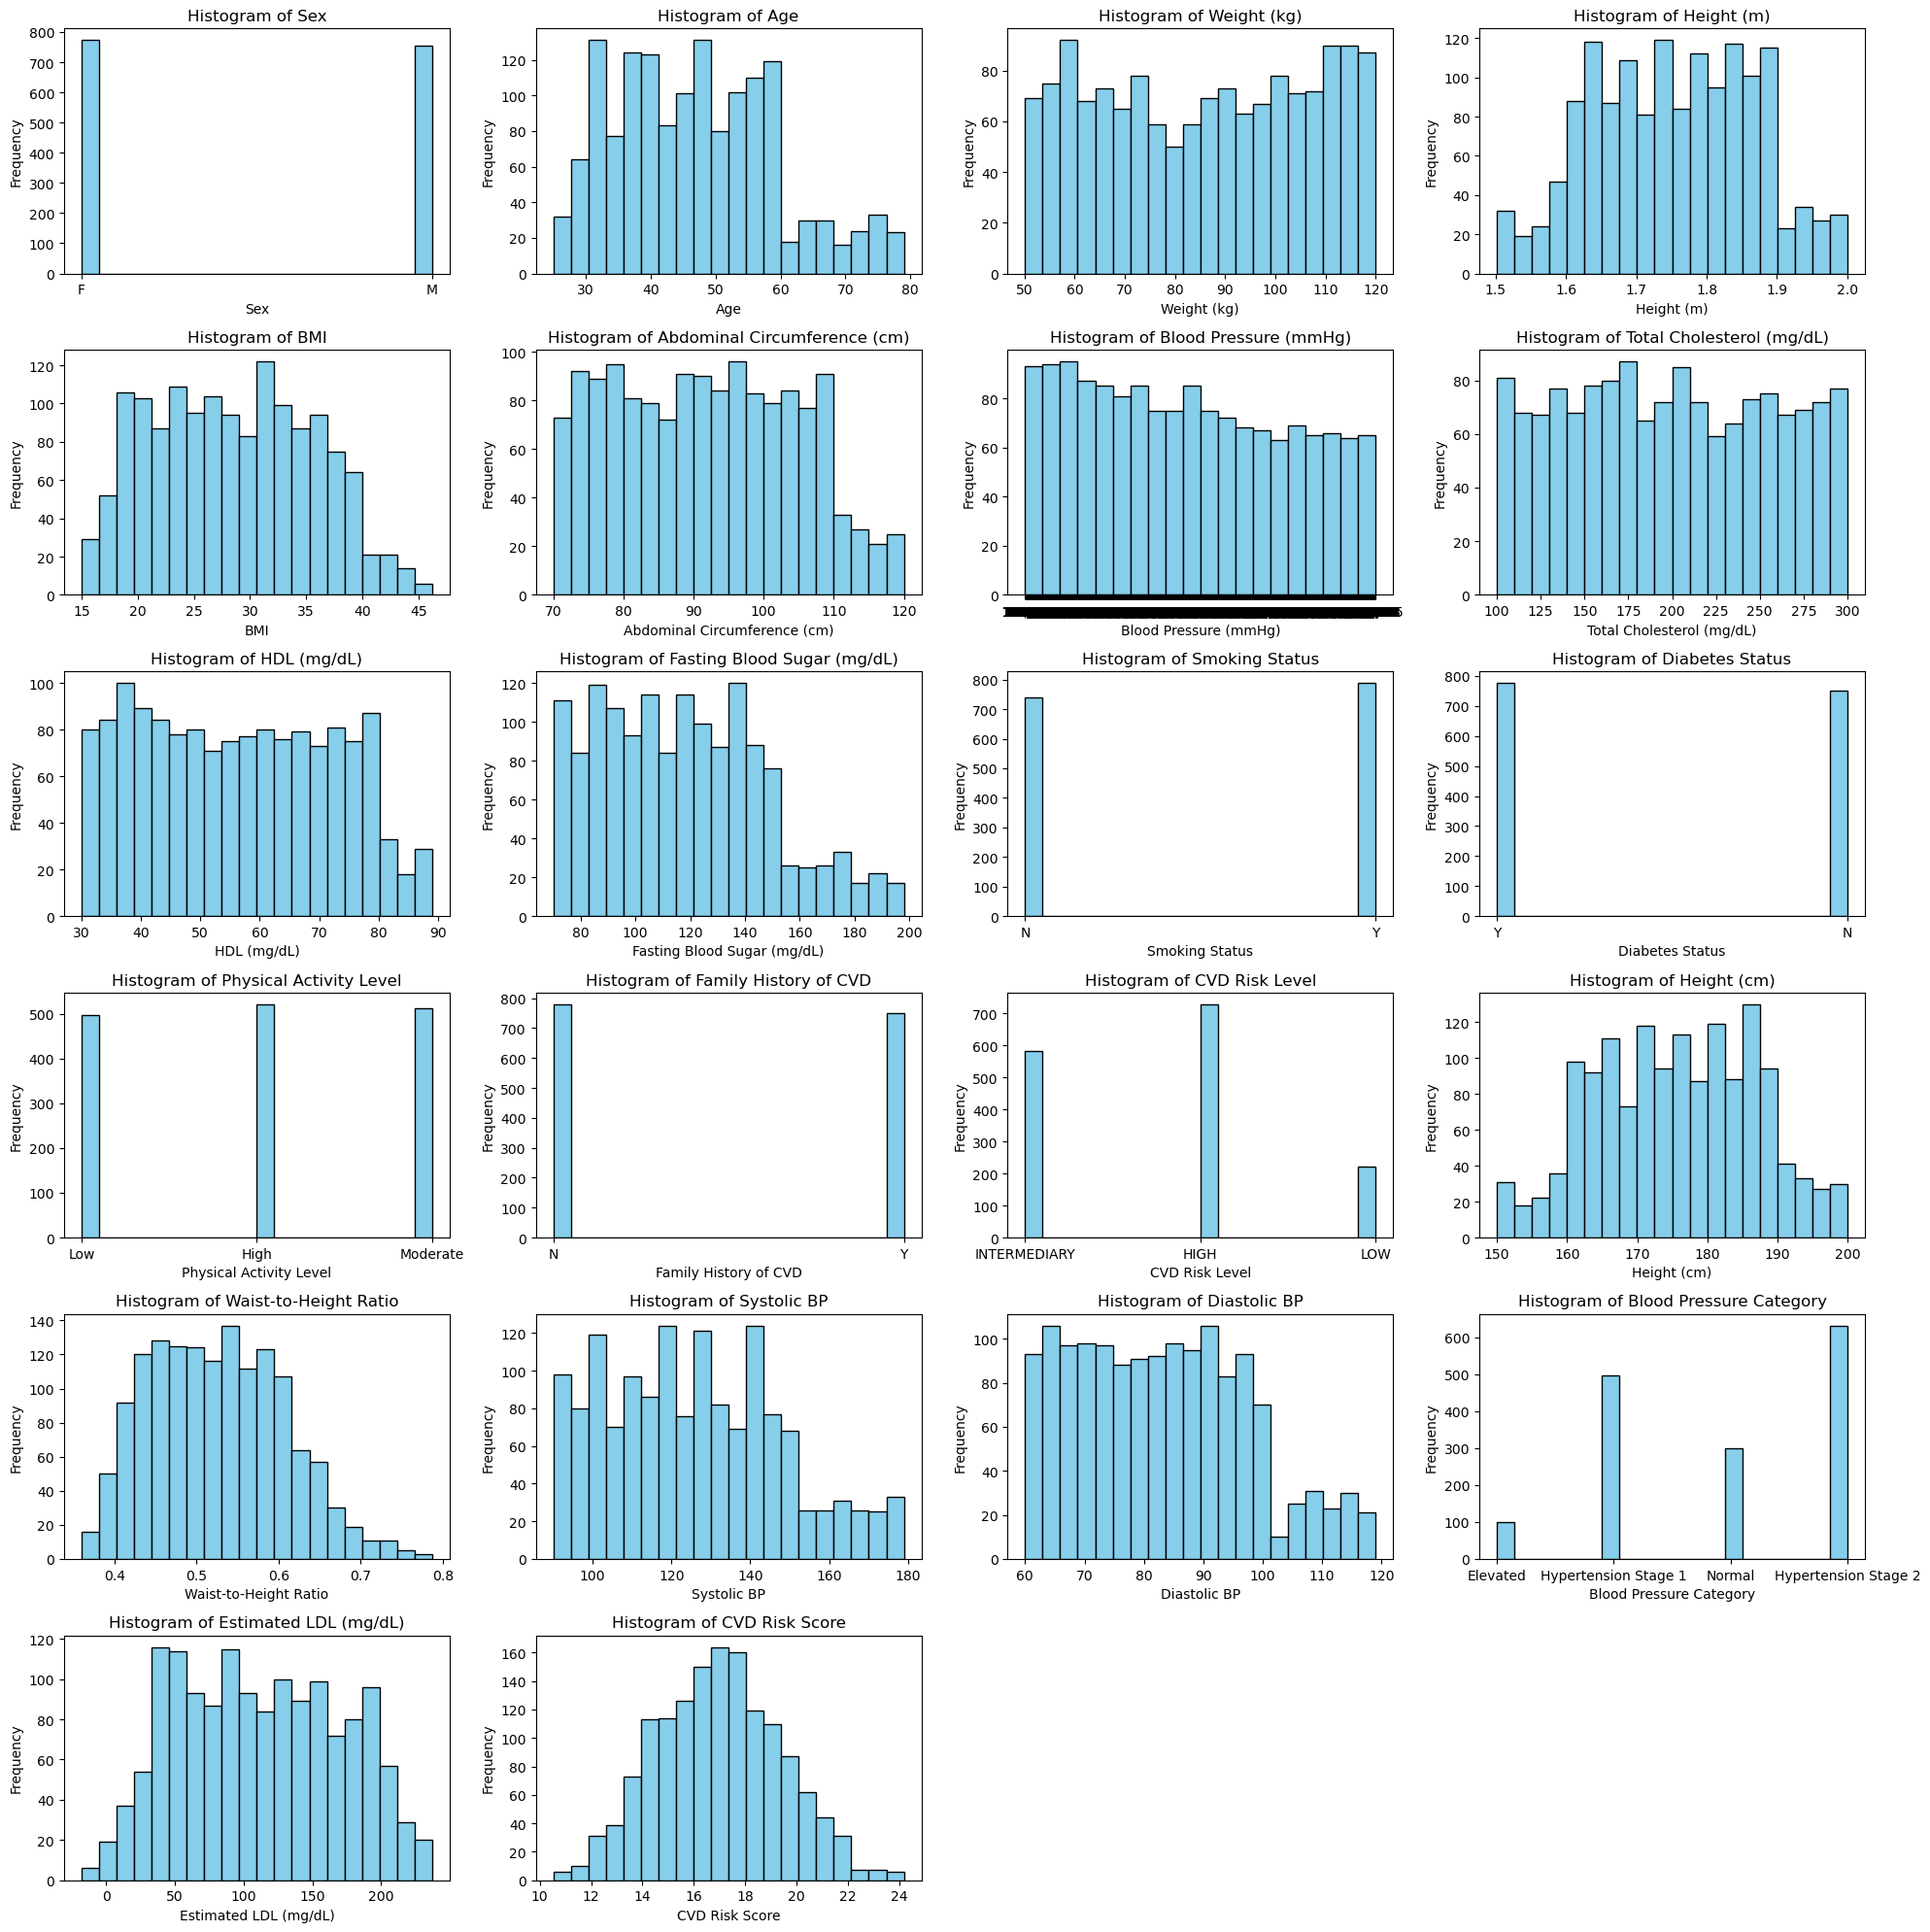

In [20]:
bld_variables = [
    "Sex",
    "Age",
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "Abdominal Circumference (cm)",
    "Blood Pressure (mmHg)",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "CVD Risk Level",
    "Height (cm)",
    "Waist-to-Height Ratio",
    "Systolic BP",
    "Diastolic BP",
    "Blood Pressure Category",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score",
]

plt.figure(figsize=(20, 20))

for i, var in enumerate(bld_variables, 1):
    plt.subplot(6, 4, i)  # Creates a 4x4 grid for histograms
    plt.hist(
        bangladesh_data[var], bins=20, color="skyblue", edgecolor="black"
    )  # Customize bins and colors as needed
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

# Adjust layout to prevent overlapping of plots
plt.tight_layout()
plt.show()

In [21]:
bangladesh_data.to_csv(
    "/Users/lilahduboff/Documents/Duke_Machine_Learning/Final/IDS705_ML_Final_Project_Cardiovasular_Disease/00_Cleaned_Data/bangladesh_cleaned_data.csv",
    index=False,
)